# EDA

## Обзор данных (data overview)

Импорт библиотек

In [29]:
import pandas as pd
import seaborn as sns

Загрузка данных

In [2]:
train = pd.read_csv("../data/raw/train.csv")

Количество объектов

In [3]:
train.shape

(891, 12)

Количество признаков

In [30]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Типы признаков


In [ ]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Статистика для числовых признаков

In [33]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Статистика для категориальных признаков

In [6]:
train.describe(include='object')

C:\Users\Владимир\AppData\Local\Temp\ipykernel_13272\1464152888.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train.describe(include='object')


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


Наличие признаков

In [7]:
train.isna().sum() 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Количество уникальных значений

In [34]:
train.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

Разделим на числовые и категориальные признаки

In [14]:
num_features = ['Age', 'Fare', 'SibSp', 'Parch']
ordinal_features = ['Pclass']
cat_features = ['Sex', 'Embarked']
drop_features = ['PassengerId']

# Признаки, возможно содержащие полезную ифнмоцию, но требующие специальной обработки
special_features = ['Name', 'Ticket', 'Cabin']

## Анализ качества данных

### Пропуски

In [8]:
train.isna().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

### Дубликаты

In [9]:
train.duplicated().sum()

np.int64(0)

### Некорректные значения

In [10]:
train.max()

PassengerId                            891
Survived                                 1
Pclass                                   3
Name           van Melkebeke, Mr. Philemon
Sex                                   male
Age                                   80.0
SibSp                                    8
Parch                                    6
Ticket                           WE/P 5735
Fare                              512.3292
Cabin                                    T
Embarked                                 S
dtype: object

In [11]:
train.min()

PassengerId                      1
Survived                         0
Pclass                           1
Name           Abbing, Mr. Anthony
Sex                         female
Age                           0.42
SibSp                            0
Parch                            0
Ticket                      110152
Fare                           0.0
Cabin                          A10
Embarked                         C
dtype: object

In [17]:
for col in cat_features + ordinal_features:
    print(train[col].value_counts())
    print()

Sex
male      577
female    314
Name: count, dtype: int64

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Pclass
3    491
1    216
2    184
Name: count, dtype: int64



## Анализ целевой переменной

In [18]:
target = 'Survived'

### Распределение классов

In [22]:
train[target].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [23]:
train[target].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Target имеет умеренный дисбаланс классов: 61.6% объектов относятся к классу 0 и 38.4% — к классу 1. Выраженного дисбаланса, требующего обязательного применения методов балансировки, не наблюдается.

### Анализ числовых признаков

Ститстики

In [25]:
train[num_features].describe()

,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


Распределения

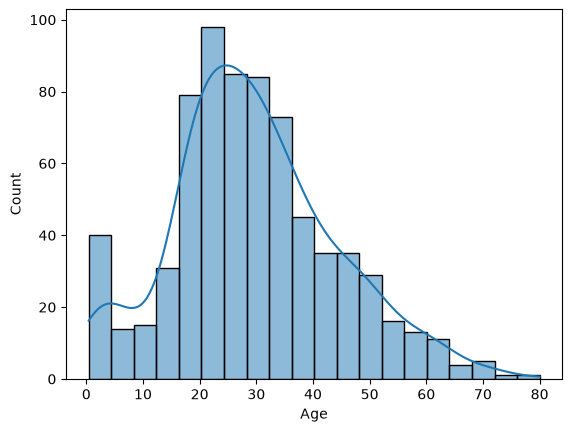

In [44]:
sns.histplot(data=train, x='Age', kde=True);

**Age**  
Тип: непрерывный числовой   
Нормальность: распредление близко к нормальному, однако правый хвост более вытянут  
Асимметрия: умеренная правосторонняя асимметрия  
Моды: выделяется околонулевая вторая мода  


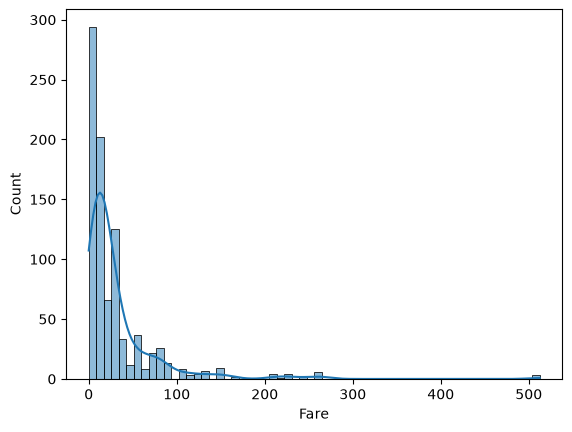

In [ ]:
sns.histplot(data=train, x='Fare', kde=True);

**Fare**  
Тип: непрерывный числовой   
Нормальность: нормальность распределения отсутствует  
Асимметрия: сильная правосторонняя асимметрия   
Моды: мода одна - околонулевая  
 

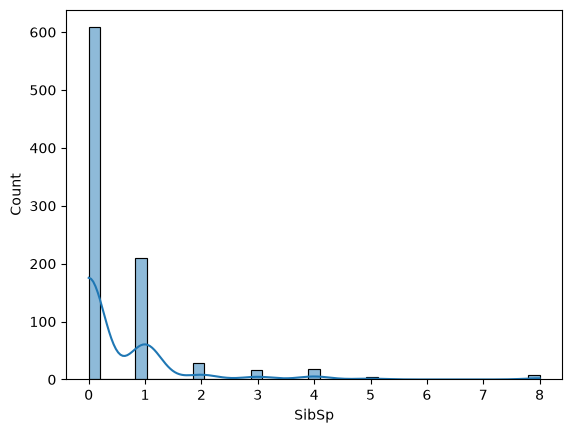

In [ ]:
sns.histplot(data=train, x='SibSp', kde=True);

**SibSp**  
Тип: дискретны числовой   
Нормальность: нормальность распределения отсутствует  
Асимметрия: сильная правосторонняя асимметрия   
Моды: мода одна - околонулевая  

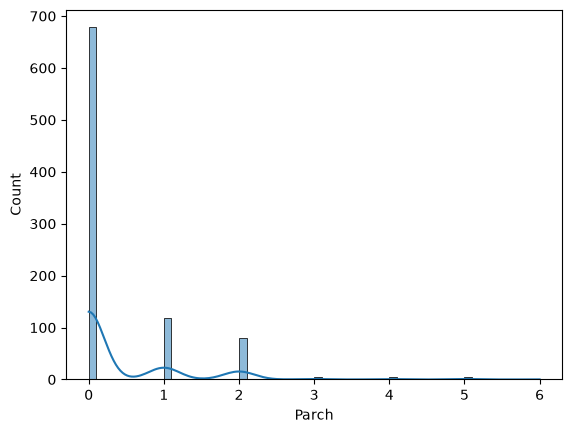

In [47]:
sns.histplot(data=train, x='Parch', kde=True);

**Parch**  
Тип: дискретны числовой   
Нормальность: нормальность распределения отсутствует  
Асимметрия: сильная правосторонняя асимметрия   
Моды: мода одна - околонулевая  

### Выбросы

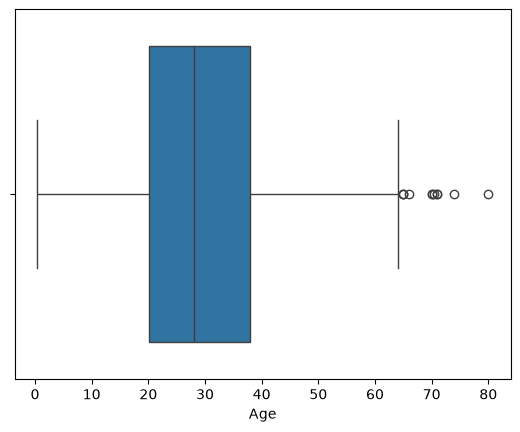

In [49]:
sns.boxplot(data=train, x='Age');

**Age**  
Наблюдаются небольшое количество редких значений, не похоже на выбросы

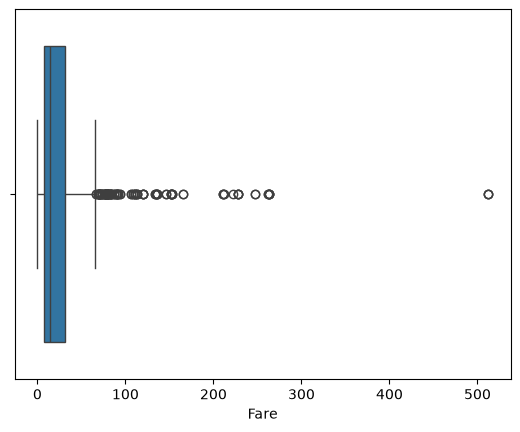

In [50]:
sns.boxplot(data=train, x='Fare');

**Fare**  
Наблюдаются множество редких значений, не похоже на выбросы

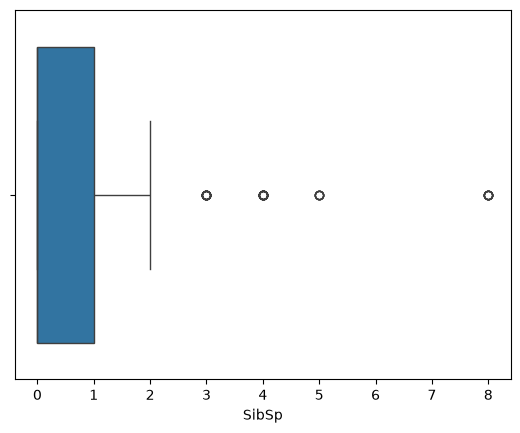

In [51]:
sns.boxplot(data=train, x='SibSp');

**SibSp**  
Наблюдаются небольшое количество редких значений, не похоже на выбросы

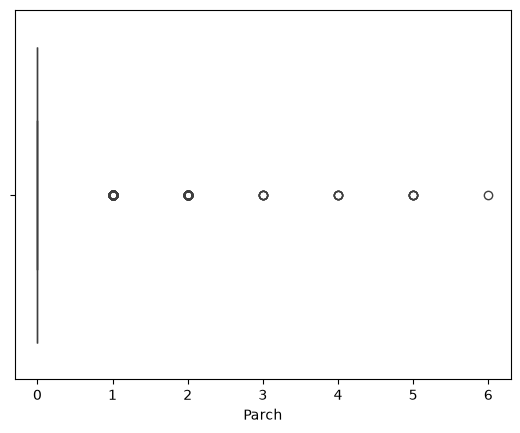

In [52]:
sns.boxplot(data=train, x='Parch');

**Parch**  
Наблюдаются небольшое количество редких значений, не похоже на выбросы